In [69]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [70]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [71]:
y_train.shape

(50000, 1)

In [72]:
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [73]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index][0]])

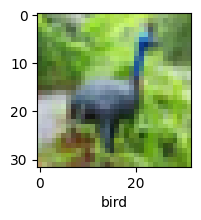

In [74]:
plot_sample(X_train, y_train, 6)

In [40]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [41]:
ann=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=5)

c:\Users\rjey0\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.3523 - loss: 1.8171
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.4269 - loss: 1.6272
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.4567 - loss: 1.5444
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.4779 - loss: 1.4843
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.4953 - loss: 1.4359


In [75]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.54      0.52      0.53      1000
           1       0.61      0.63      0.62      1000
           2       0.47      0.24      0.32      1000
           3       0.29      0.40      0.34      1000
           4       0.51      0.23      0.32      1000
           5       0.30      0.47      0.37      1000
           6       0.71      0.22      0.34      1000
           7       0.46      0.62      0.53      1000
           8       0.46      0.76      0.58      1000
           9       0.59      0.49      0.53      1000

    accuracy                           0.46     10000
   macro avg       0.50      0.46      0.45     10000
weighted avg       0.50      0.46      0.45     10000



In [77]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [78]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.3727 - loss: 1.9821
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5331 - loss: 1.3250
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5983 - loss: 1.1544
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6379 - loss: 1.0443
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.6717 - loss: 0.9486
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6934 - loss: 0.8887
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7144 - loss: 0.8256
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7354 - loss: 0.7752
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7478 - loss: 0.7254
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7660 - loss: 0.6732


In [79]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6357 - loss: 1.2024


[1.2023565769195557, 0.635699987411499]

In [80]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[1.1550636e-03, 2.6491698e-04, 1.4813222e-02, 6.3818461e-01,
        4.5561930e-03, 3.1875205e-01, 1.3267142e-02, 6.5236459e-03,
        1.5333587e-03, 9.4977883e-04],
       [1.7308276e-02, 3.2872802e-01, 8.3267029e-09, 1.5342442e-06,
        1.1720150e-09, 9.1141800e-08, 3.2435804e-10, 1.1380427e-08,
        4.1564232e-01, 2.3831983e-01],
       [1.0220778e-01, 3.8677242e-01, 1.9057004e-03, 2.9225114e-03,
        2.2048768e-04, 3.1161299e-03, 3.9983328e-04, 7.8857969e-04,
        1.0174496e-01, 3.9992160e-01],
       [4.1563967e-01, 2.3256201e-01, 2.6441846e-04, 2.6510877e-03,
        1.5828919e-03, 1.3432060e-03, 1.0547195e-04, 5.1458296e-03,
        3.7814301e-02, 3.0289099e-01],
       [2.6124368e-05, 1.3965525e-06, 3.8992133e-02, 2.0743706e-03,
        8.5513711e-01, 1.0087619e-03, 1.0263793e-01, 1.2049362e-04,
        4.5374372e-07, 1.2337071e-06]], dtype=float32)

In [81]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(9), np.int64(0), np.int64(4)]